# Import libraries 

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import re

# Ignore warnings for cleaner output
warnings.simplefilter('ignore')

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder

from sklearn.model_selection import train_test_split

In [16]:
train_df = pd.read_csv('credit_train.csv')
train_df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15.0,0.0,253460.0,427174.0,0.0,0.0


In [17]:
test_df = pd.read_csv('credit_test.csv')
test_df.head()
test_df.columns

Index(['Loan ID', 'Customer ID', 'Current Loan Amount', 'Term', 'Credit Score',
       'Annual Income', 'Years in current job', 'Home Ownership', 'Purpose',
       'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens'],
      dtype='object')

testing 

In [18]:
def preprocess(df):
    import numpy as np
    import pandas as pd
    import re

    df = df.copy()
    df.columns = df.columns.str.strip()

    # Drop IDs
    df = df.drop(columns=['Loan ID', 'Customer ID'], errors='ignore')

    # Standardize nulls
    df.replace(['nan','NaN','NULL','',' '], np.nan, inplace=True)

    # ---------------------------
    # Years in current job
    # ---------------------------
    def extract_years(s):
        s = str(s)
        match = re.findall(r'\d+', s)
        return int(match[0]) if match else 0

    df['Years in current job'] = df['Years in current job'].apply(extract_years)

    df['Years in current job'] = pd.cut(
        df['Years in current job'],
        bins=[-1, 2, 5, 10, float('inf')],
        labels=['0-2', '2-5', '5-10', '10+']
    )

    # ---------------------------
    # Purpose mapping
    # ---------------------------
    if 'Purpose' in df.columns:
        purpose_map = {
            'Home Improvements':'Home Renovation / Improvement',
            'Debt Consolidation':'Debt Consolidation',
            'Buy House':'Home Purchase / Mortgage',
            'Business Loan':'Business / Startup Capital',
            'Buy a Car':'Car / Vehicle Purchase',
            'Take a Trip':'Vacation / Travel',
            'small_business':'Business / Startup Capital',
            'Medical Bills':'Medical Expenses',
            'wedding':'Wedding Expenses',
            'vacation':'Vacation / Travel',
            'Educational Expenses':'Education / Tuition Fees',
            'moving':'Moving / Relocation Costs',
            'other':'Other / Miscellaneous',
            'Other':'Other / Miscellaneous',
            'renewable_energy':'Buying Electronics / Appliances',
            'major_purchase':'Business / Startup Capital'
        }

        df['Purpose'] = df['Purpose'].replace(purpose_map)

    return df

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

In [20]:
num_cols = [
    'Current Loan Amount', 'Credit Score', 'Annual Income',
    'Monthly Debt', 'Years of Credit History',
    'Months since last delinquent', 'Number of Open Accounts',
    'Number of Credit Problems', 'Current Credit Balance',
    'Maximum Open Credit', 'Bankruptcies', 'Tax Liens'
]

cat_cols = ['Term', 'Home Ownership', 'Purpose']
ord_cols = ['Years in current job']

In [21]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(categories=[['0-2','2-5','5-10','10+']]))
])

In [22]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
    ('ord', ord_pipeline, ord_cols)
])

In [23]:
model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
    # ('classifier', RandomForestClassifier(n_estimators=50, random_state=42))
])

In [24]:
train_df = preprocess(train_df)

print("NaNs per column:\n", train_df.isna().sum())
print("Total NaNs:", train_df.isna().sum().sum())

NaNs per column:
 Loan Status                       514
Current Loan Amount               514
Term                              514
Credit Score                    19668
Annual Income                   19668
Years in current job                0
Home Ownership                    514
Purpose                           514
Monthly Debt                      514
Years of Credit History           514
Months since last delinquent    53655
Number of Open Accounts           514
Number of Credit Problems         514
Current Credit Balance            514
Maximum Open Credit               516
Bankruptcies                      718
Tax Liens                         524
dtype: int64
Total NaNs: 99889


In [25]:
train_df = preprocess(train_df)

# 🔥 IMPORTANT
train_df = train_df.dropna(subset=['Loan Status'])

X = train_df.drop('Loan Status', axis=1)
y = train_df['Loan Status']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Current Loan Amount',
                                                   'Credit Score',
                                                   'Annual Income',
                                                   'Monthly Debt',
                                                   'Years of Credit History',
                                                   'Months since last '
                                                   'delinquent',
                                                   'Number of Open Accounts',
                                                   'Number of Credit Problems',
                                                   'Current Credit Balance',
                                                   'Maximum Open Credit',
                                                   'Bankru...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Term', 'Home Ownership',
                                                   'Purpose']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[['0-2',
                                                                                               '2-5',
                                                                                               '5-10',
                                                                                               '10+']]))]),
                                                  ['Years in current job'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

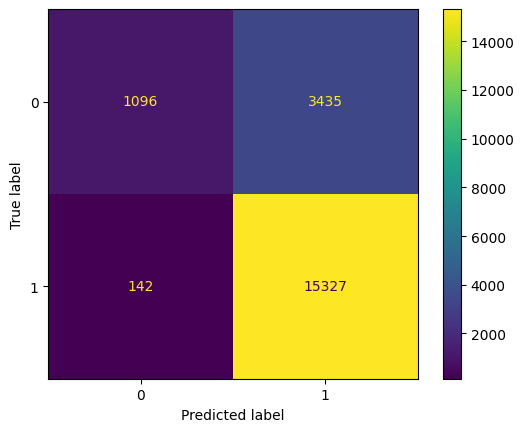

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions on TRAIN (or validation set)
y_pred = model.predict(X_val)

cm = confusion_matrix(y_val, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [27]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy: 0.82115
              precision    recall  f1-score   support

 Charged Off       0.89      0.24      0.38      4531
  Fully Paid       0.82      0.99      0.90     15469

    accuracy                           0.82     20000
   macro avg       0.85      0.62      0.64     20000
weighted avg       0.83      0.82      0.78     20000



In [28]:
import joblib

joblib.dump(model, "loan_model_small.pkl", compress=3)

['loan_model_small.pkl']